# Arabic Tashkeel Restoration

# Imports & Settings

In [1]:
import os, re, time, pickle, random, csv
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Config

In [2]:
SEED = 42

DATA_DIR = Path("data")

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
CACHE_DIR = PROJECT_DIR / "cache"

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

FAST_MODE = True

if FAST_MODE:
    MAX_LINES_PER_SPLIT = 30000
    MAX_LEN = 100
    EMBEDDING_DIM = 96
    HIDDEN_DIM = 128
    BATCH_SIZE = 128
    EPOCHS = 5
    USE_ATTENTION = False
else:
    MAX_LINES_PER_SPLIT = 200000
    MAX_LEN = 160
    EMBEDDING_DIM = 192
    HIDDEN_DIM = 256
    BATCH_SIZE = 128
    EPOCHS = 15
    USE_ATTENTION = True

MIN_LABEL_FREQUENCY = 5
LEARNING_RATE = 1e-3
DROPOUT = 0.25

PAD_CHAR_ID = 0
PAD_LABEL_ID = -100

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dataset:", DATA_DIR)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("FAST_MODE:", FAST_MODE)

Dataset: data
Device: cuda
GPU: Quadro T2000
FAST_MODE: True


# Text Processing

In [3]:
DIACRITICS_PATTERN = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670]")
ARABIC_KEEP_PATTERN = re.compile(r"[^\u0600-\u06FF\u064B-\u0652\u0670\s\.,،؛؟!]")
SPACE_PATTERN = re.compile(r"\s+")

DIACRITIC_ORDER = {
    "\u064b": 0,
    "\u064c": 1,
    "\u064d": 2,
    "\u064e": 3,
    "\u064f": 4,
    "\u0650": 5,
    "\u0651": 6,
    "\u0652": 7,
    "\u0670": 8,
}

def normalize_diacritics(label: str) -> str:
    if not label:
        return ""
    
    unique_marks = []
    
    for char in label:
        if char not in unique_marks:
            unique_marks.append(char)
    
    return "".join(sorted(unique_marks, key=lambda ch: DIACRITIC_ORDER.get(ch, 99)))

def clean_line(line: str) -> str:
    line = ARABIC_KEEP_PATTERN.sub(" ", line.strip())
    line = SPACE_PATTERN.sub(" ", line)
    return line.strip()

def remove_tashkeel(text: str) -> str:
    return DIACRITICS_PATTERN.sub("", text)

def split_text_and_labels(line: str):
    text_chars = []
    labels = []
    
    for char in line:
        if DIACRITICS_PATTERN.fullmatch(char):
            if labels:
                labels[-1] = normalize_diacritics(labels[-1] + char)
            continue
        
        text_chars.append(char)
        labels.append("")
    
    return "".join(text_chars), labels

def chunk_sequence(text, labels, max_len):
    chunks = []
    
    for start in range(0, len(text), max_len):
        chunk_text = text[start:start + max_len]
        chunk_labels = labels[start:start + max_len]
        
        if len(chunk_text) >= 2:
            chunks.append((chunk_text, chunk_labels))
    
    return chunks

print("Preprocessing functions loaded.")

Preprocessing functions loaded.


# Load Train / Valid / Test

In [4]:
TRAIN_FILES = [
    DATA_DIR / "CA" / "train.csv",
    DATA_DIR / "MSA" / "train.csv",
]

VALID_FILES = [
    DATA_DIR / "CA" / "vali.csv",
    DATA_DIR / "MSA" / "vali.csv",
]

TEST_FILES = [
    DATA_DIR / "CA" / "test.csv",
    DATA_DIR / "MSA" / "test.csv",
]

def load_csv_lines(file_paths, max_lines=None):
    lines = []

    for file_path in file_paths:
        print("Checking:", file_path)

        if not file_path.exists():
            print("❌ Missing file:", file_path)
            continue

        print("✅ Loading:", file_path)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            reader = csv.reader(f)

            for row in reader:
                if not row:
                    continue

                full_row_text = " ".join(row)
                line = clean_line(full_row_text)

                if len(line) >= 2:
                    lines.append(line)

                if max_lines is not None and len(lines) >= max_lines:
                    break

    return lines

train_raw_lines = load_csv_lines(TRAIN_FILES, MAX_LINES_PER_SPLIT)
valid_raw_lines = load_csv_lines(VALID_FILES, MAX_LINES_PER_SPLIT)
test_raw_lines = load_csv_lines(TEST_FILES, MAX_LINES_PER_SPLIT)

print("Train raw lines:", len(train_raw_lines))
print("Valid raw lines:", len(valid_raw_lines))
print("Test raw lines :", len(test_raw_lines))

if len(train_raw_lines) > 0:
    print("Example:", train_raw_lines[0][:300])
else:
    
    raise ValueError("No training lines loaded. Check DATA_DIR and file names.")

Checking: data\CA\train.csv
✅ Loading: data\CA\train.csv
Checking: data\MSA\train.csv
✅ Loading: data\MSA\train.csv
Checking: data\CA\vali.csv
✅ Loading: data\CA\vali.csv
Checking: data\MSA\vali.csv
✅ Loading: data\MSA\vali.csv
Checking: data\CA\test.csv
✅ Loading: data\CA\test.csv
Checking: data\MSA\test.csv
✅ Loading: data\MSA\test.csv
Train raw lines: 30000
Valid raw lines: 30000
Test raw lines : 30000
Example: وَفِي بَعْضِ النُّسَخِ بِالْإِضَافَةِ فَصَالَحَ الرَّجُلُ الْمَرِيضَ عَلَى جُرْحِهِ فِي حَالِ مَرَضِهِ مِنْ الْجُرْحِ بِ مَالٍ قَدْرِ أَرْشِهِ أَيْ دِيَةِ الْجُرْحِ أَوْ غَيْرِهِ أَيْ الْأَرْشِ صَادِقٌ بِأَقَلَّ وَأَكْثَرَ مِنْهُ ثُمَّ مَاتَ الْمَرِيضُ مِنْ مَرَضِهِ مِنْ ذَلِكَ الْجُرْحِ جَازَ صُلْح


# Preprocessing 

In [5]:
def preprocess_lines(raw_lines, split_name):
    cache_path = CACHE_DIR / f"{split_name}_lines{len(raw_lines)}_len{MAX_LEN}_fixed.pkl"

    if cache_path.exists():
        print("Loading cache:", cache_path)
        with open(cache_path, "rb") as f:
            cached = pickle.load(f)
        return cached["texts"], cached["label_lines"]

    texts = []
    label_lines = []

    skipped_no_tashkeel = 0

    for line in tqdm(raw_lines, desc=f"Preprocessing {split_name}"):
        if not DIACRITICS_PATTERN.search(line):
            skipped_no_tashkeel += 1
            continue

        text, labels = split_text_and_labels(line)

        if len(text) < 2:
            continue

        if all(label == "" for label in labels):
            skipped_no_tashkeel += 1
            continue

        for chunk_text, chunk_labels in chunk_sequence(text, labels, MAX_LEN):
            texts.append(chunk_text)
            label_lines.append(chunk_labels)

    print(f"{split_name} skipped no tashkeel:", skipped_no_tashkeel)

    with open(cache_path, "wb") as f:
        pickle.dump(
            {
                "texts": texts,
                "label_lines": label_lines,
            },
            f
        )

    return texts, label_lines

train_texts, train_label_lines = preprocess_lines(train_raw_lines, "train")
valid_texts, valid_label_lines = preprocess_lines(valid_raw_lines, "valid")
test_texts, test_label_lines = preprocess_lines(test_raw_lines, "test")

print("Train samples:", len(train_texts))
print("Valid samples:", len(valid_texts))
print("Test samples :", len(test_texts))

if len(train_texts) == 0:
    raise ValueError("train_texts is empty. Your train.csv may not contain tashkeel/diacritics.")

print("Example text:", train_texts[0][:200])
print("Example labels:", train_label_lines[0][:40])

Preprocessing train:   0%|          | 0/30000 [00:00<?, ?it/s]

train skipped no tashkeel: 0


Preprocessing valid:   0%|          | 0/30000 [00:00<?, ?it/s]

valid skipped no tashkeel: 0


Preprocessing test:   0%|          | 0/30000 [00:00<?, ?it/s]

test skipped no tashkeel: 0
Train samples: 36595
Valid samples: 36628
Test samples : 36457
Example text: وفي بعض النسخ بالإضافة فصالح الرجل المريض على جرحه في حال مرضه من الجرح ب مال قدر أرشه أي دية الجرح 
Example labels: ['َ', 'ِ', '', '', 'َ', 'ْ', 'ِ', '', '', '', 'ُّ', 'َ', 'ِ', '', 'ِ', '', 'ْ', 'ِ', 'َ', '', 'َ', 'ِ', '', 'َ', 'َ', '', 'َ', 'َ', '', '', '', 'َّ', 'ُ', 'ُ', '', '', 'ْ', 'َ', 'ِ', '']


In [6]:
import shutil

if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)

CACHE_DIR.mkdir(exist_ok=True)

# Build Vocabulary and Labels

In [7]:
all_train_text = "".join(train_texts)

chars = sorted(set(all_train_text))

char2idx = {char: idx + 1 for idx, char in enumerate(chars)}
idx2char = {idx: char for char, idx in char2idx.items()}

label_counter = Counter(label for labels in train_label_lines for label in labels)

def normalize_label_lines(label_lines):
    normalized = []
    
    for labels in label_lines:
        row = []
        
        for label in labels:
            if label and label_counter[label] < MIN_LABEL_FREQUENCY:
                row.append("")
            else:
                row.append(label)
        
        normalized.append(row)
    
    return normalized

train_label_lines = normalize_label_lines(train_label_lines)
valid_label_lines = normalize_label_lines(valid_label_lines)
test_label_lines = normalize_label_lines(test_label_lines)

unique_labels = sorted(set(label for labels in train_label_lines for label in labels))

if "" in unique_labels:
    unique_labels.remove("")

unique_labels = [""] + unique_labels

label2idx = {label: idx for idx, label in enumerate(unique_labels)}
idx2label = {idx: label for label, idx in label2idx.items()}

print("Vocab size:", len(char2idx) + 1)
print("Number of labels:", len(label2idx))

for label, idx in label2idx.items():
    print(repr(label), "->", idx)

Vocab size: 38
Number of labels: 15
'' -> 0
'ً' -> 1
'ًّ' -> 2
'ٌ' -> 3
'ٌّ' -> 4
'ٍ' -> 5
'ٍّ' -> 6
'َ' -> 7
'َّ' -> 8
'ُ' -> 9
'ُّ' -> 10
'ِ' -> 11
'ِّ' -> 12
'ّ' -> 13
'ْ' -> 14


# Encode Data

In [8]:
def encode_texts(texts):
    return [[char2idx.get(ch, PAD_CHAR_ID) for ch in text] for text in texts]

def encode_labels(label_lines):
    return [[label2idx.get(label, 0) for label in labels] for labels in label_lines]

train_encoded_texts = encode_texts(train_texts)
valid_encoded_texts = encode_texts(valid_texts)
test_encoded_texts = encode_texts(test_texts)

train_encoded_labels = encode_labels(train_label_lines)
valid_encoded_labels = encode_labels(valid_label_lines)
test_encoded_labels = encode_labels(test_label_lines)

print("Encoding done.")

Encoding done.


# Dataset and DataLoader

In [9]:
class TashkeelDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_batch(batch):
    batch_x, batch_y = zip(*batch)
    
    max_len = min(max(len(x) for x in batch_x), MAX_LEN)
    
    x_tensor = torch.zeros((len(batch_x), max_len), dtype=torch.long)
    y_tensor = torch.full((len(batch_y), max_len), PAD_LABEL_ID, dtype=torch.long)
    
    for i, (x, y) in enumerate(zip(batch_x, batch_y)):
        x = x[:max_len]
        y = y[:max_len]
        
        x_tensor[i, :len(x)] = torch.tensor(x, dtype=torch.long)
        y_tensor[i, :len(y)] = torch.tensor(y, dtype=torch.long)
    
    return x_tensor, y_tensor

train_dataset = TashkeelDataset(train_encoded_texts, train_encoded_labels)
valid_dataset = TashkeelDataset(valid_encoded_texts, valid_encoded_labels)
test_dataset = TashkeelDataset(test_encoded_texts, test_encoded_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    pin_memory=torch.cuda.is_available(),
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    pin_memory=torch.cuda.is_available(),
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    pin_memory=torch.cuda.is_available(),
    num_workers=0
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 36595
Valid: 36628
Test : 36457


# Model

In [10]:
class BiLSTMTashkeelModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_labels,
        embedding_dim=128,
        hidden_dim=256,
        dropout=0.25,
        use_attention=False
    ):
        super().__init__()
        
        self.use_attention = use_attention
        
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_CHAR_ID
        )
        
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        model_dim = hidden_dim * 2
        
        if use_attention:
            self.attention = nn.MultiheadAttention(
                model_dim,
                num_heads=4,
                dropout=dropout,
                batch_first=True
            )
            self.norm = nn.LayerNorm(model_dim)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(model_dim, num_labels)

    def forward(self, x):
        pad_mask = x.eq(PAD_CHAR_ID)
        
        x = self.embedding(x)
        x, _ = self.lstm(x)
        
        if self.use_attention:
            attn_out, _ = self.attention(
                x,
                x,
                x,
                key_padding_mask=pad_mask,
                need_weights=False
            )
            x = self.norm(x + attn_out)
        
        x = self.dropout(x)
        return self.fc(x)

vocab_size = len(char2idx) + 1
num_labels = len(label2idx)

model = BiLSTMTashkeelModel(
    vocab_size=vocab_size,
    num_labels=num_labels,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    use_attention=USE_ATTENTION
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_LABEL_ID)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

BiLSTMTashkeelModel(
  (embedding): Embedding(38, 96, padding_idx=0)
  (lstm): LSTM(96, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=15, bias=True)
)
Trainable parameters: 238927


# Training Functions

In [11]:
def batch_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=-1)
    mask = labels.ne(PAD_LABEL_ID)
    
    correct = ((preds == labels) & mask).sum().item()
    total = mask.sum().item()
    
    return correct, total

def run_eval(loader, max_batches=None):
    model.eval()
    
    total_correct = 0
    total_count = 0
    total_loss = 0
    batches = 0
    
    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break
            
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            logits = model(x)
            
            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1)
            )
            
            correct, count = batch_accuracy(logits, y)
            
            total_correct += correct
            total_count += count
            total_loss += loss.item()
            batches += 1
    
    return total_loss / max(batches, 1), total_correct / max(total_count, 1)

def train_one_epoch(loader, scaler=None):
    model.train()
    
    total_correct = 0
    total_count = 0
    total_loss = 0
    
    use_amp = scaler is not None and torch.cuda.is_available()
    
    for x, y in tqdm(loader, desc="Training", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(
                    logits.reshape(-1, logits.shape[-1]),
                    y.reshape(-1)
                )
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        
        else:
            logits = model(x)
            loss = criterion(
                logits.reshape(-1, logits.shape[-1]),
                y.reshape(-1)
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        correct, count = batch_accuracy(logits, y)
        
        total_correct += correct
        total_count += count
        total_loss += loss.item()
    
    return total_loss / max(len(loader), 1), total_correct / max(total_count, 1)

# Train Model

In [12]:
BEST_MODEL_PATH = MODEL_DIR / "best_tashkeel_model.pt"
ARTIFACTS_PATH = MODEL_DIR / "tashkeel_artifacts.pkl"

best_valid_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    
    train_loss, train_acc = train_one_epoch(train_loader, scaler=scaler)
    
    valid_loss, valid_acc = run_eval(
        valid_loader,
        max_batches=None if not FAST_MODE else 30
    )
    
    scheduler.step(valid_acc)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | "
        f"Time: {time.time() - start:.1f}s"
    )
    
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved:", BEST_MODEL_PATH)

print("Best validation accuracy:", round(best_valid_acc, 4))

C:\Users\houda\AppData\Local\Temp\ipykernel_18632\237878469.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


Training:   0%|          | 0/286 [00:00<?, ?it/s]

C:\Users\houda\AppData\Local\Temp\ipykernel_18632\1165291748.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/5 | Train Loss: 0.7539 | Train Acc: 0.7487 | Valid Loss: 0.4178 | Valid Acc: 0.8593 | Time: 18.3s
Best model saved: d:\NLP Project\arabic tashkeel project\models\best_tashkeel_model.pt


Training:   0%|          | 0/286 [00:00<?, ?it/s]

...

Epoch 03/5 | Train Loss: 0.3036 | Train Acc: 0.8991 | Valid Loss: 0.2584 | Valid Acc: 0.9142 | Time: 17.0s
Best model saved: d:\NLP Project\arabic tashkeel project\models\best_tashkeel_model.pt


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Epoch 04/5 | Train Loss: 0.2688 | Train Acc: 0.9109 | Valid Loss: 0.2332 | Valid Acc: 0.9227 | Time: 17.3s
Best model saved: d:\NLP Project\arabic tashkeel project\models\best_tashkeel_model.pt


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Epoch 05/5 | Train Loss: 0.2469 | Train Acc: 0.9184 | Valid Loss: 0.2168 | Valid Acc: 0.9286 | Time: 17.0s
Best model saved: d:\NLP Project\arabic tashkeel project\models\best_tashkeel_model.pt
Best validation accuracy: 0.9286


# Test Evaluation

In [14]:
if BEST_MODEL_PATH.exists():
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

test_loss, test_acc = run_eval(
    test_loader,
    max_batches=None if not FAST_MODE else 50
)

model.eval()

all_preds = []
all_labels = []

MAX_REPORT_BATCHES = None if not FAST_MODE else 50

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(tqdm(test_loader, desc="Collecting predictions")):
        if MAX_REPORT_BATCHES is not None and batch_idx >= MAX_REPORT_BATCHES:
            break
        
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        logits = model(x)
        preds = torch.argmax(logits, dim=-1)
        
        mask = y.ne(PAD_LABEL_ID)
        
        all_preds.extend(preds[mask].cpu().numpy().tolist())
        all_labels.extend(y[mask].cpu().numpy().tolist())

label_names = [
    "No_Diacritic" if idx2label[i] == "" else idx2label[i]
    for i in range(len(idx2label))
]

report = classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(label_names))),
    target_names=label_names,
    zero_division=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print(report)

with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("Report Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Test Loss: 0.2171
Test Accuracy: 0.9288
              precision    recall  f1-score   support

No_Diacritic       0.99      1.00      0.99    132239
           ً       0.89      0.75      0.82      2201
          ًّ       0.81      0.45      0.58       104
           ٌ       0.66      0.61      0.64      1812
          ٌّ       0.73      0.09      0.16       124
           ٍ       0.71      0.73      0.72      2569
          ٍّ       0.54      0.09      0.15       152
           َ       0.91      0.93      0.92    102525
          َّ       0.89      0.84      0.87     12005
           ُ       0.85      0.79      0.82     27772
          ُّ       0.74      0.60      0.66      1635
           ِ       0.89      0.90      0.90     46987
          ِّ       0.76      0.57      0.65      2314
           ّ       0.00      0.00      0.00       255
           ْ       0.92      0.95      0.93     42422

    accuracy                           0.93    375116
   macro avg       0.75      0.62      0

# Curves

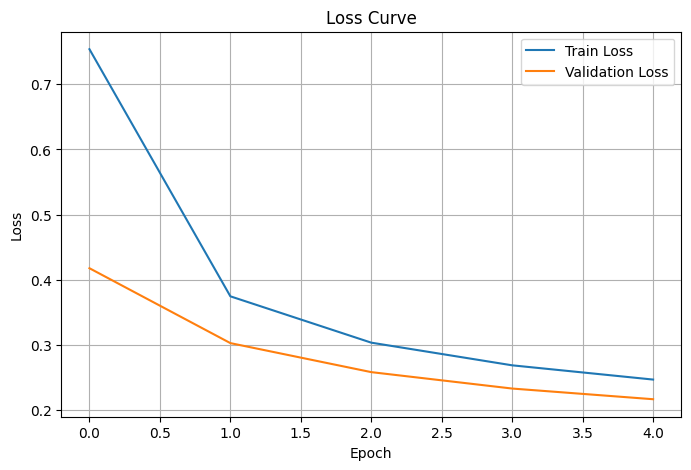

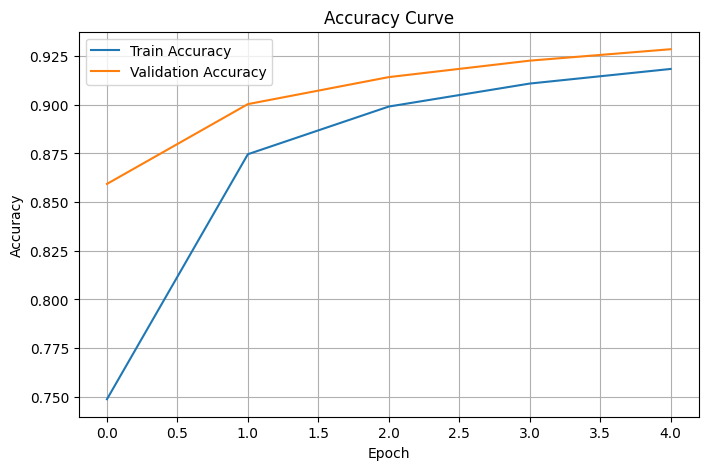

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["valid_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["valid_acc"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix

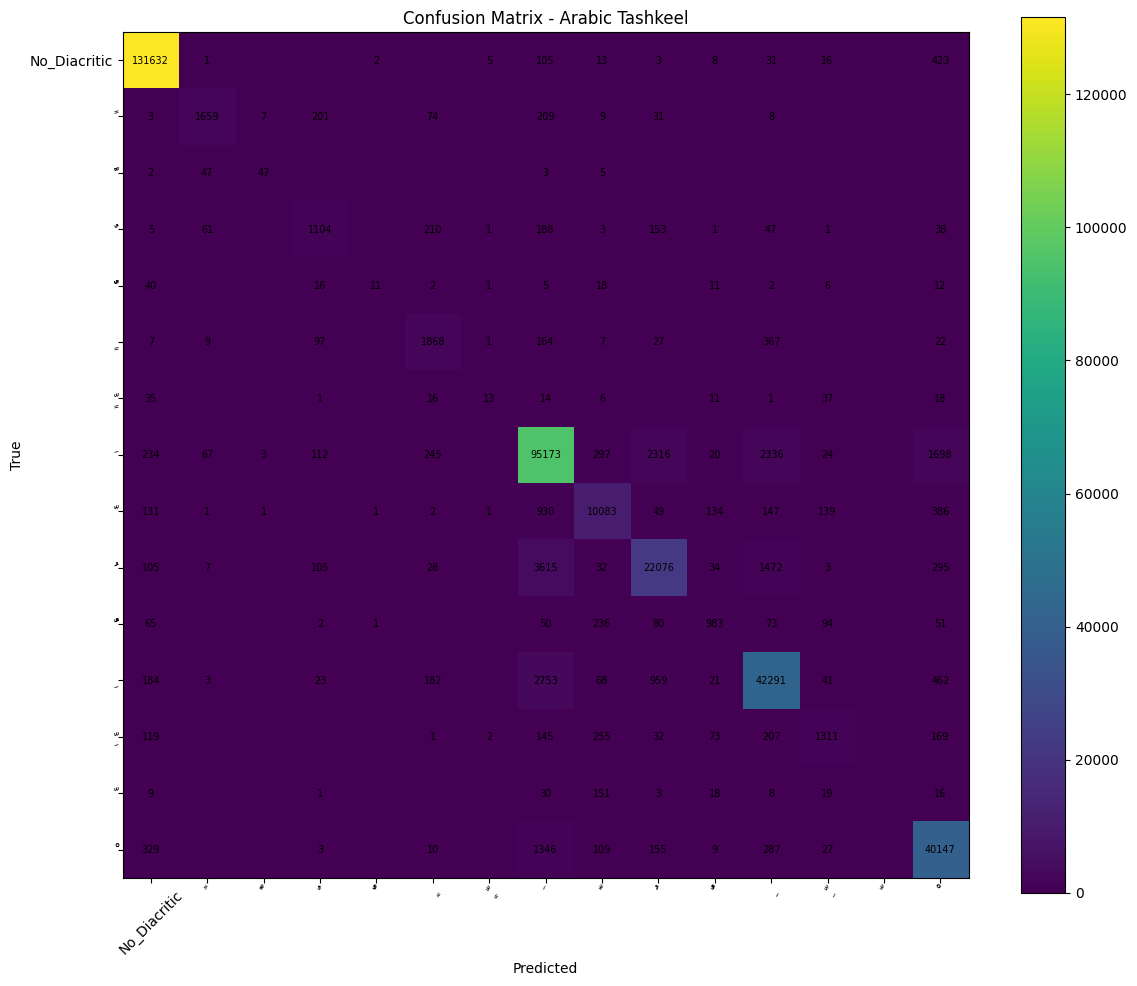

In [16]:
cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(len(label_names)))
)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Confusion Matrix - Arabic Tashkeel")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.yticks(range(len(label_names)), label_names)

for i in range(len(label_names)):
    for j in range(len(label_names)):
        value = cm[i, j]
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=7)

plt.colorbar()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300)
plt.show()

# Save Artifacts

In [17]:
artifacts = {
    "char2idx": char2idx,
    "idx2char": idx2char,
    "label2idx": label2idx,
    "idx2label": idx2label,
    "pad_char_id": PAD_CHAR_ID,
    "pad_label_id": PAD_LABEL_ID,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "use_attention": USE_ATTENTION,
    "vocab_size": vocab_size,
    "num_labels": num_labels,
    "history": history,
    "metrics": {
        "test_accuracy": float(test_acc),
        "report_accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    }
}

with open(ARTIFACTS_PATH, "wb") as f:
    pickle.dump(artifacts, f)

summary_lines = [
    "Arabic Tashkeel Restoration Project",
    "Model: BiLSTM + Optional Attention",
    "",
    f"FAST_MODE: {FAST_MODE}",
    f"MAX_LINES_PER_SPLIT: {MAX_LINES_PER_SPLIT}",
    f"MAX_LEN: {MAX_LEN}",
    f"EMBEDDING_DIM: {EMBEDDING_DIM}",
    f"HIDDEN_DIM: {HIDDEN_DIM}",
    f"BATCH_SIZE: {BATCH_SIZE}",
    f"EPOCHS: {EPOCHS}",
    f"USE_ATTENTION: {USE_ATTENTION}",
    "",
    f"Train Samples: {len(train_dataset)}",
    f"Valid Samples: {len(valid_dataset)}",
    f"Test Samples: {len(test_dataset)}",
    "",
    f"Test Accuracy: {test_acc:.4f}",
    f"Report Accuracy: {accuracy:.4f}",
    f"Macro F1-score: {macro_f1:.4f}",
    f"Weighted F1-score: {weighted_f1:.4f}",
    f"Number of Classes: {len(label_names)}",
]

summary_text = "\n".join(summary_lines)

with open(OUTPUT_DIR / "results_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved model:", BEST_MODEL_PATH)
print("Saved artifacts:", ARTIFACTS_PATH)

Arabic Tashkeel Restoration Project
Model: BiLSTM + Optional Attention

FAST_MODE: True
MAX_LINES_PER_SPLIT: 30000
MAX_LEN: 100
EMBEDDING_DIM: 96
HIDDEN_DIM: 128
BATCH_SIZE: 128
EPOCHS: 5
USE_ATTENTION: False

Train Samples: 36595
Valid Samples: 36628
Test Samples: 36457

Test Accuracy: 0.9288
Report Accuracy: 0.9288
Macro F1-score: 0.6534
Weighted F1-score: 0.9274
Number of Classes: 15
Saved model: d:\NLP Project\arabic tashkeel project\models\best_tashkeel_model.pt
Saved artifacts: d:\NLP Project\arabic tashkeel project\models\tashkeel_artifacts.pkl


# Prediction Function

In [18]:
def prepare_input_text(text):
    return remove_tashkeel(clean_line(text))

def predict_tashkeel(text, return_confidence=False):
    model.eval()
    
    cleaned = prepare_input_text(text)
    
    if not cleaned:
        return ("", 0.0) if return_confidence else ""
    
    pieces = []
    confidences = []
    
    for start in range(0, len(cleaned), MAX_LEN):
        chunk = cleaned[start:start + MAX_LEN]
        
        ids = [char2idx.get(ch, PAD_CHAR_ID) for ch in chunk]
        x = torch.tensor([ids], dtype=torch.long).to(device)
        
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=-1)
            
            pred_ids = torch.argmax(probs, dim=-1)[0].cpu().numpy().tolist()
            conf = torch.max(probs, dim=-1).values[0].cpu().numpy().tolist()
        
        for ch, pred_id, c in zip(chunk, pred_ids, conf):
            pieces.append(ch)
            pieces.append(idx2label.get(int(pred_id), ""))
            confidences.append(float(c))
    
    output = "".join(pieces)
    avg_conf = float(np.mean(confidences)) if confidences else 0.0
    
    return (output, avg_conf) if return_confidence else output

# Test Examples

In [19]:
examples = [
    "بسم الله الرحمن الرحيم",
    "الحمد لله رب العالمين",
    "اللغة العربية لغة جميلة",
    "ذهب الطالب الى المدرسة",
]

for sentence in examples:
    output, conf = predict_tashkeel(sentence, return_confidence=True)
    
    print("Input :", sentence)
    print("Output:", output)
    print("Confidence:", round(conf * 100, 2), "%")
    print("-" * 60)

Input : بسم الله الرحمن الرحيم
Output: بِسَمِ اللَّهِ الرَّحْمِنُ الرَّحِيمُ
Confidence: 84.57 %
------------------------------------------------------------
Input : الحمد لله رب العالمين
Output: الْحَمْدُ لِلَّهُ رَبُّ الْعَالِمِيِّنَ
Confidence: 84.8 %
------------------------------------------------------------
Input : اللغة العربية لغة جميلة
Output: اللَّغَةِ الْعَرْبِيَّةُ لَغَةَ جَمِيلَةٍ
Confidence: 86.37 %
------------------------------------------------------------
Input : ذهب الطالب الى المدرسة
Output: ذَهَبَ الطَّالِبُ الَّىُّ الْمَدْرَسَةِ
Confidence: 83.26 %
------------------------------------------------------------


# User Input

In [20]:
user_text = input("Enter Arabic text without tashkeel: ")

output, conf = predict_tashkeel(user_text, return_confidence=True)

print("Input :", user_text)
print("Output:", output)
print("Confidence:", round(conf * 100, 2), "%")

Input : الحمدلله
Output: الْحَمْدَلِلِهِ
Confidence: 85.48 %
